<a href="https://colab.research.google.com/github/broadinstitute/BE3D/blob/main/examples/BE3Dv8_MultiScreen_MEN1_Notebook_temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README
Repo: https://github.com/broadinstitute/BE3D \
Paper: https://www.nature.com/articles/s41586-023-05755-9 \
This example is based on 2 CBE screens which tile MEN1

# Setup

In [ ]:
# @title Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# @title Install DSSP and ClustalO

! apt-get update
! apt-get install dssp clustalo


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,946 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,927 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 http://archive.ubuntu.com

In [ ]:
# @title Install MUSCLE

! wget https://github.com/rcedgar/muscle/releases/download/v5.3/muscle-linux-x86.v5.3
! chmod +x muscle-linux-x86.v5.3
! mv muscle-linux-x86.v5.3 muscle


--2026-03-26 18:52:10--  https://github.com/rcedgar/muscle/releases/download/v5.3/muscle-linux-x86.v5.3
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/378508080/9dc41df9-b517-49e5-8af6-0cab933dbe43?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-26T19%3A42%3A14Z&rscd=attachment%3B+filename%3Dmuscle-linux-x86.v5.3&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-26T18%3A42%3A01Z&ske=2026-03-26T19%3A42%3A14Z&sks=b&skv=2018-11-09&sig=36bAxD2hYvCrfTTuVlW7IWM36pW3iWr36H3V4O6QrDM%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDU1MTQzMCwibmJmIjoxNzc0NTUxMTMwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvb

In [ ]:
# @title Install BE3D

! pip install git+https://github.com/broadinstitute/beclust3d-public.git
print('beclust3d installed at:')
! pip show beclust3d


  Cloning https://github.com/broadinstitute/beclust3d-public.git to /tmp/pip-req-build-f2mvbftr
  Running command git clone --filter=blob:none --quiet https://github.com/broadinstitute/beclust3d-public.git /tmp/pip-req-build-f2mvbftr
  Resolved https://github.com/broadinstitute/beclust3d-public.git to commit 1116d6bd226c6b6bb610697e32455c7a2ec7fe7c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.3 MB/s eta 0:00:00
  Created wheel for beclust3d: filename=beclust3d-1.0.0-py3-none-any.whl size=764270 sha256=c8f5df2fd95d6cabfc83b0dd18e09758232cf97b90b33a2bd6a02aadef1e9d00
  Stored in directory: /tmp/pip-ephem-wheel-cache-oe4lqe4d/wheels/f1/a7/29/932b67d47922e277bd8c92943ec17ff5105d711c221cc4f642
  Created wheel for wget: filename=

In [ ]:
# @title Import packages

import os
import sys
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import uuid
import ipywidgets as widgets
from IPython.display import display

from IPython.display import Image, display, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from google.colab import files
import shutil

from beclust3d import *

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

plt.rcParams['font.family'] = 'DejaVu Sans'


In [ ]:
# @title Download relevant files for running BE3D

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py -O be3d_display_yaml.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py -O be3d_helper.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_qa.py -O be3d_qa.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_calculate_lfc3d.py -O beclust3d_calculate_lfc3d.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_nonaggregate.py -O beclust3d_nonaggregate.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/beclust3d_characterization.py -O beclust3d_characterization.py

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/bemetaclust3d_metaaggregate.py -O bemetaclust3d_metaaggregate.py
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/bemetaclust3d_characterization.py -O bemetaclust3d_characterization.py


--2026-03-26 18:52:36--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_display_yaml.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18139 (18K) [text/plain]
Saving to: ‘be3d_display_yaml.py’

be3d_display_yaml.p 100%[===================>]  17.71K  --.-KB/s    in 0s      

2026-03-26 18:52:36 (37.7 MB/s) - ‘be3d_display_yaml.py’ saved [18139/18139]

--2026-03-26 18:52:36--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/be3d_helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting resp

# BE3D Inputs (MEN1)

In [ ]:
# @title Download relevant files for MEN1

! mkdir MEN1/
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/yaml/MEN1-Perner2023.yaml -O MEN1/MEN1-Perner2023.yaml
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/men1.fasta -O MEN1/men1.fasta
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/pdb/men1.pdb -O MEN1/men1.pdb
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/PernerNature2023-MOLM13-Screen.tsv -O MEN1/PernerNature2023-MOLM13-Screen.tsv
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/PernerNature2023-MV411-Screen.tsv -O MEN1/PernerNature2023-MV411-Screen.tsv


--2026-03-26 18:56:25--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/yaml/MEN1-Perner2023.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7159 (7.0K) [text/plain]
Saving to: ‘MEN1/MEN1-Perner2023.yaml’

MEN1/MEN1-Perner202 100%[===================>]   6.99K  --.-KB/s    in 0s      

2026-03-26 18:56:25 (61.3 MB/s) - ‘MEN1/MEN1-Perner2023.yaml’ saved [7159/7159]

--2026-03-26 18:56:25--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/data/men1.fasta
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

In [ ]:
# @title Display Input .yaml File

from be3d_display_yaml import display_yaml_config

# @markdown Path to downloaded or user-input .yaml configuration file
yaml_config_filepath = "MEN1/MEN1-Perner2023.yaml" # @param {type:"string"}
display_yaml_config(yaml_config_filepath)

with open(yaml_config_filepath, 'r') as file:
    input_dict = yaml.safe_load(file)

output_dir = input_dict['output_dir']
input_gene = input_dict['input_gene']

# @markdown To edit BE3D inputs, open the Files tab, open the yaml config file, change the variables, and save the file.


# BE3D Run (MEN1)

MEN1/MEN1-Perner2023.yaml and /content/MEN1/MEN1-Perner2023.yaml are the same file.
All results will be saved in the following directory: /content/MEN1/
Output from beclust3d.lfc3d.structure is saved in the following directory: /content/MEN1/sequence_structure/
Output from beclust3d.qc.hypothesis_tests is saved in the following directory: /content/MEN1/hypothesis_qc/
BE-QA complete: sequence/structural features and hypothesis tests


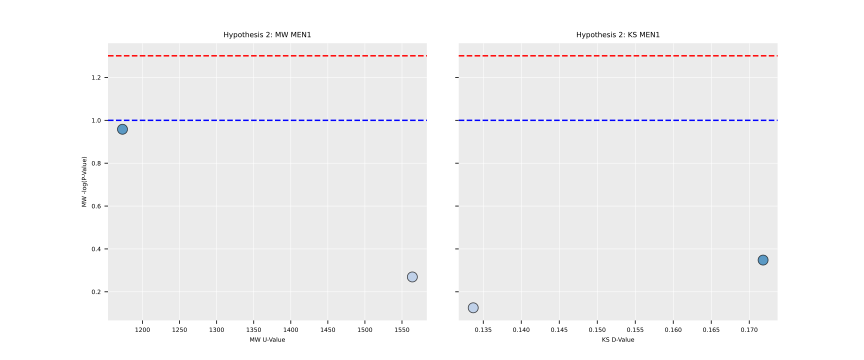

In [ ]:
# @title BE-QA and Visualizations
# @markdown Description

! python be3d_qa.py {yaml_config_filepath}

display(SVG(filename=f'{output_dir}hypothesis_qc/hypothesis2_scatterplot_by_gene_name.svg'))


All results will be saved in the following directory: /content/MEN1/
Processing PernerNature2023-MOLM13-Screen
{'Nonsense': 19, 'Splice': 11, 'Missense': 238, 'Silent': 84, 'No Mutation': 97, 'Intron': 56}
Processing PernerNature2023-MV411-Screen
{'Nonsense': 19, 'Splice': 11, 'Missense': 238, 'Silent': 84, 'No Mutation': 97, 'Intron': 56}
Output from beclust3d.lfc3d.preprocess_data is saved in the following directory: /content/MEN1/screendata/
-----[SANITARY CHECK]-----
#of missense edits:193,              #of mapped missense edits:193,              #of not mapped missense edits:0,              list of not mapped missense edits: []
-----[SANITARY CHECK]-----
#of missense edits:193,              #of mapped missense edits:193,              #of not mapped missense edits:0,              list of not mapped missense edits: []
Output from beclust3d.lfc3d.randomize_data is saved in the following directory: /content/MEN1/screendata_rand/
Output from beclust3d.lfc3d.prioritize_sequence is saved

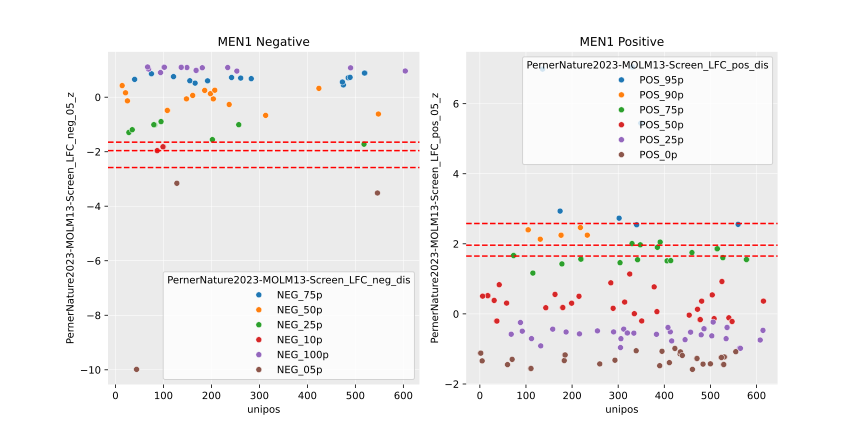

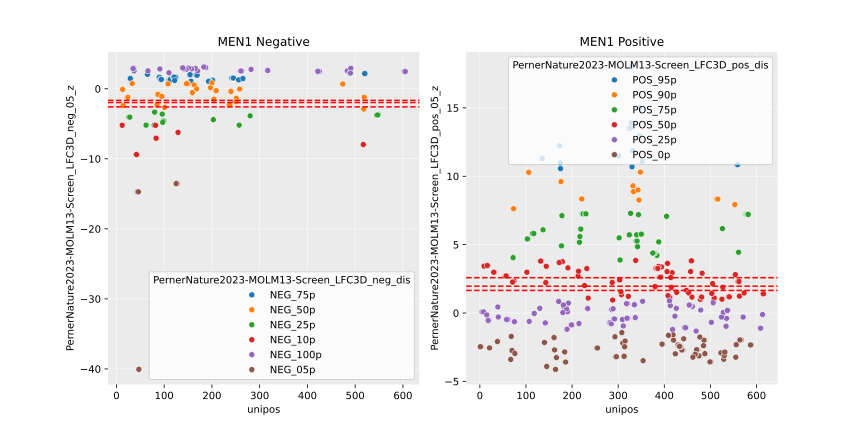

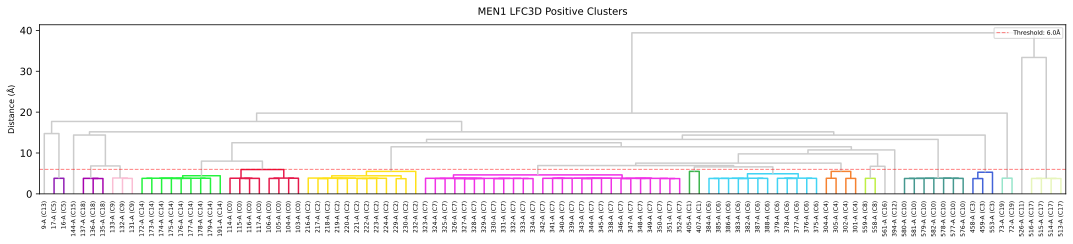

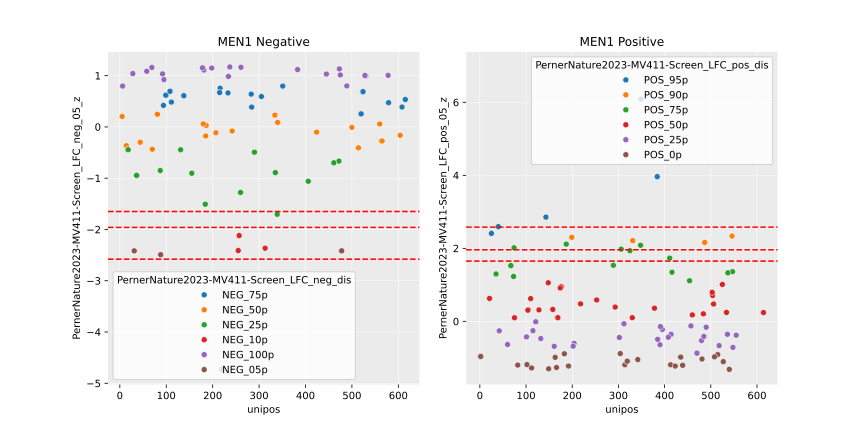

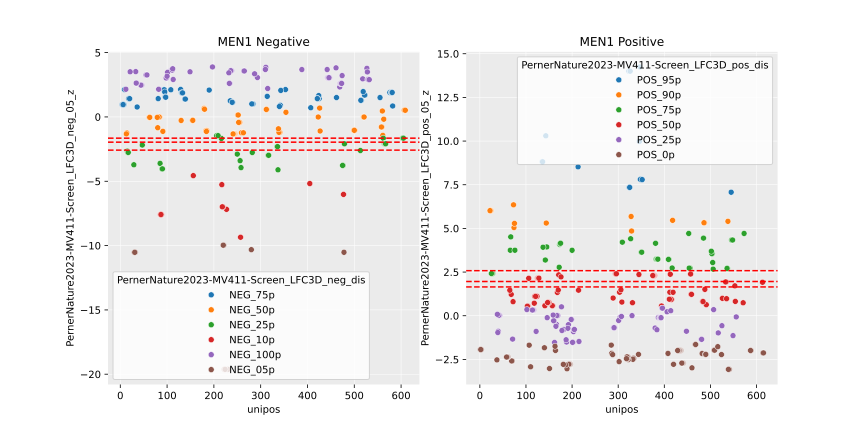

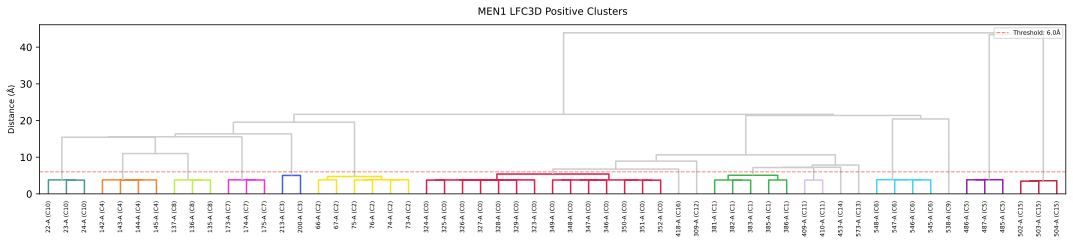

In [ ]:
# @title BE-Clust3D and Visualizations
# @markdown Description

! python beclust3d_calculate_lfc3d.py {yaml_config_filepath}
! python beclust3d_nonaggregate.py {yaml_config_filepath}

screen_name = 'PernerNature2023-MOLM13-Screen'
display(SVG(filename=f'{output_dir}LFC/plots/{input_gene}_{screen_name}_LFC_cutoff05_scatter_colored.svg'))
display(SVG(filename=f'{output_dir}LFC3D/plots/{input_gene}_{screen_name}_LFC3D_cutoff05_scatter_colored.svg'))
display(SVG(filename=f'{output_dir}cluster_LFC3D/plots/{input_gene}_{screen_name}_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))

screen_name = 'PernerNature2023-MV411-Screen'
display(SVG(filename=f'{output_dir}LFC/plots/{input_gene}_{screen_name}_LFC_cutoff05_scatter_colored.svg'))
display(SVG(filename=f'{output_dir}LFC3D/plots/{input_gene}_{screen_name}_LFC3D_cutoff05_scatter_colored.svg'))
display(SVG(filename=f'{output_dir}cluster_LFC3D/plots/{input_gene}_{screen_name}_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))



All results will be saved in the following directory: /content/MEN1/
Output from beclust3d.lfc3d.characterization is saved in the following directory: /content/MEN1/characterization/
Step 3b complete: per-screen characterization done


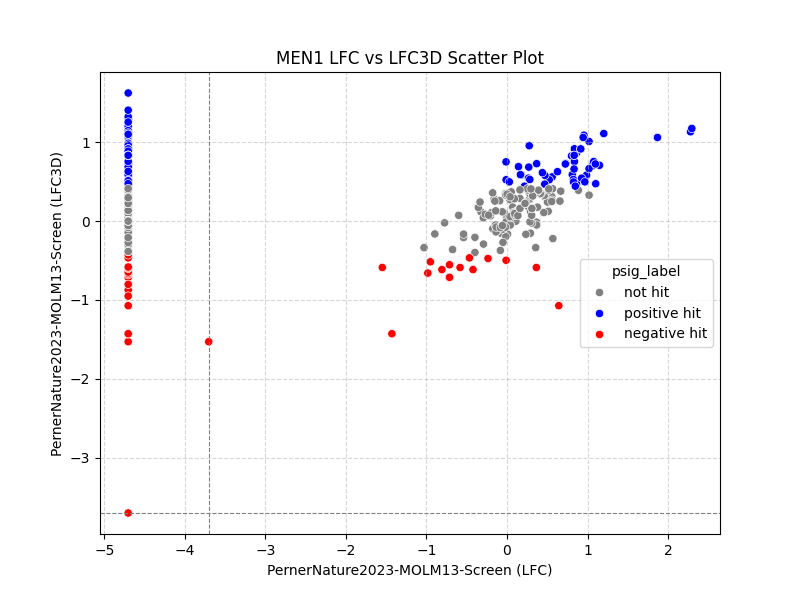

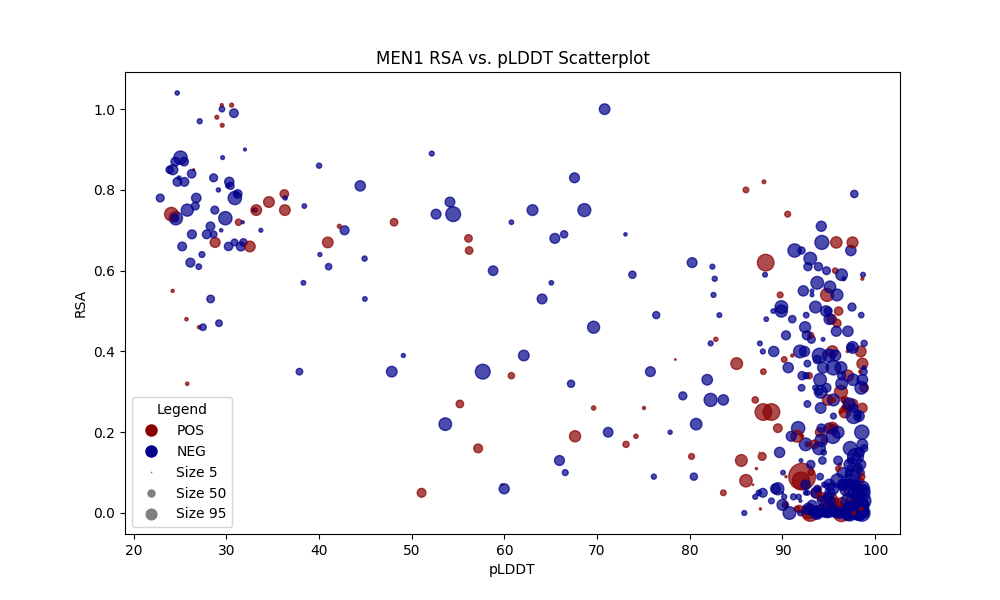

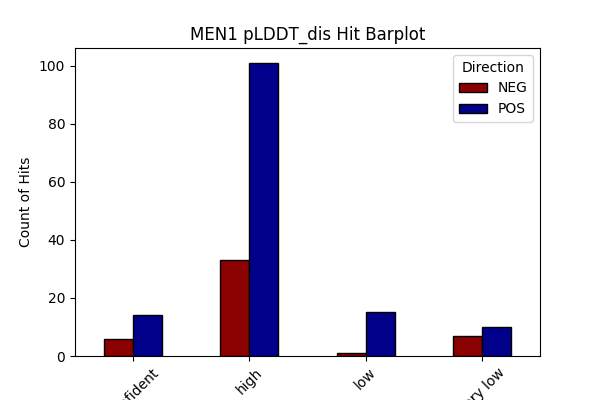

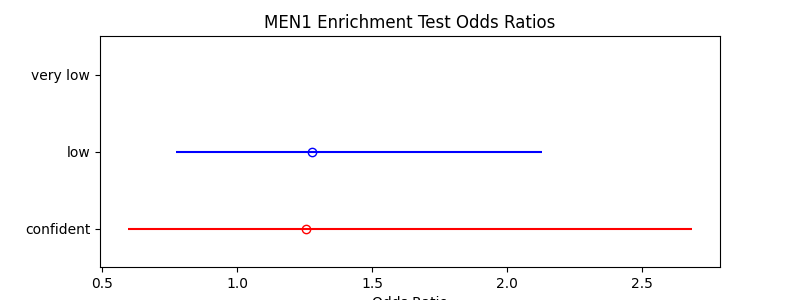

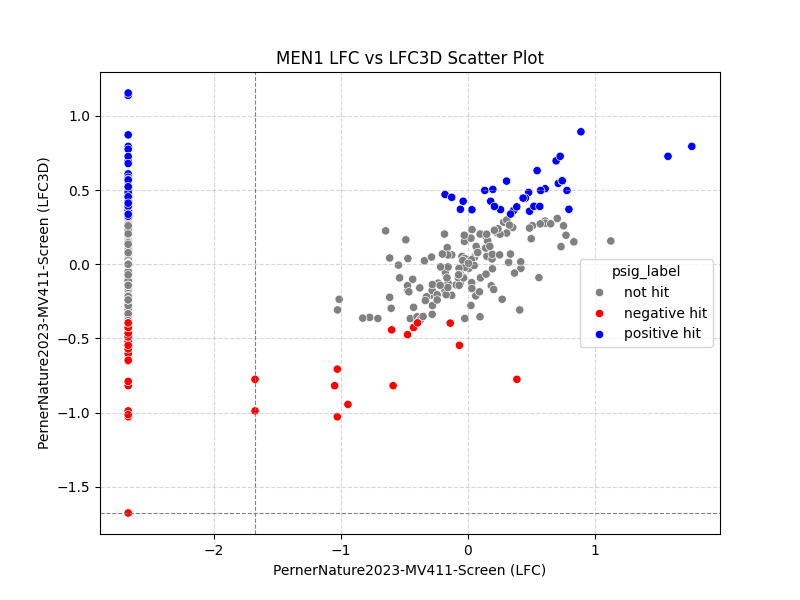

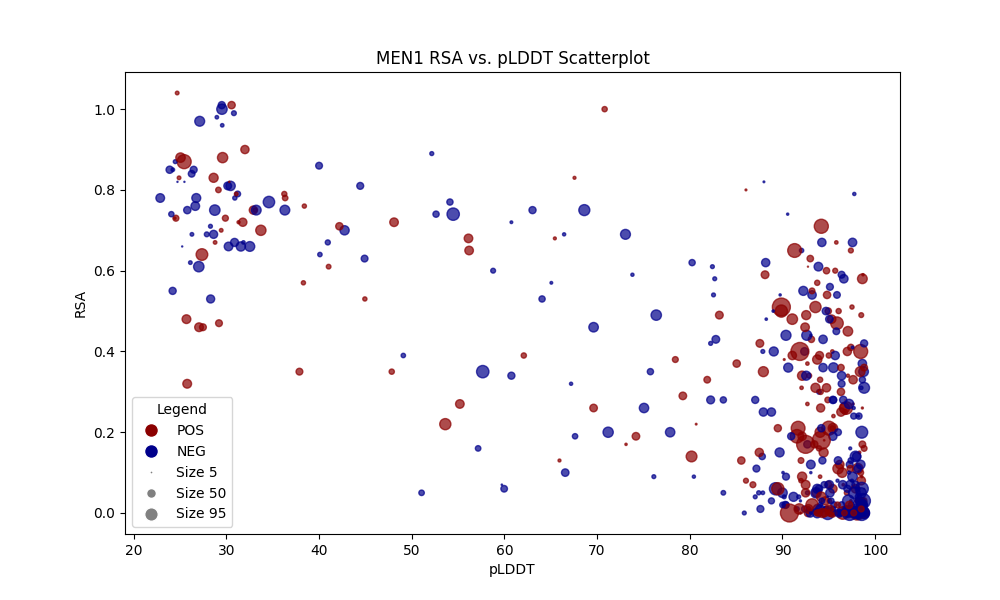

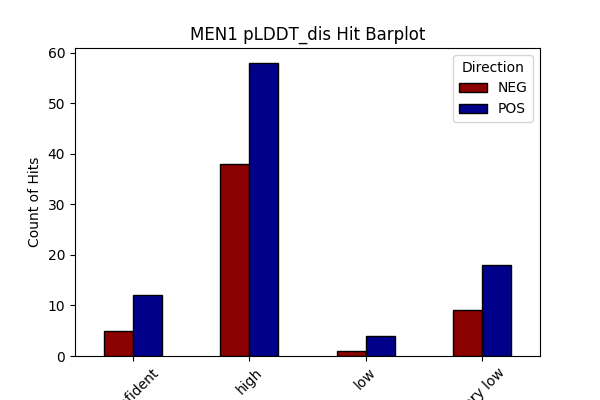

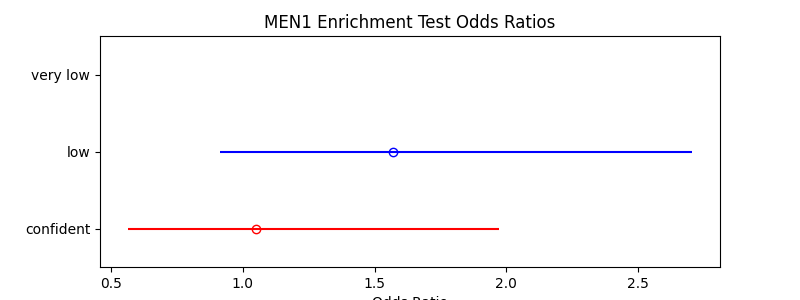

In [ ]:
# @title BEClust3D Characterization and Visualizations

! python beclust3d_characterization.py {yaml_config_filepath}

screen_name = 'PernerNature2023-MOLM13-Screen'
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_05_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_05_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_05_{screen_name}.png'))

screen_name = 'PernerNature2023-MV411-Screen'
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_05_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_05_{screen_name}.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_05_{screen_name}.png'))


All results will be saved in the following directory: /content/MEN1/
Output from beclust3d.aggregate.metaaggregate is saved in the following directory: /content/MEN1/meta-aggregate/
Output from beclust3d.aggregate.aggregate_plot is saved in the following directory: /content/MEN1/meta-aggregate/
Output from beclust3d.aggregate.metaaggregate is saved in the following directory: /content/MEN1/meta-aggregate/
Output from beclust3d.aggregate.aggregate_plot is saved in the following directory: /content/MEN1/meta-aggregate/
Output from beclust3d.lfc3d.clustering is saved in the following directory: /content/MEN1/cluster_LFC/
Output from beclust3d.lfc3d.clustering is saved in the following directory: /content/MEN1/cluster_LFC3D/
Output from beclust3d.lfc3d.clustering is saved in the following directory: /content/MEN1/cluster_union/
Step 3a complete: meta-aggregation and clustering done


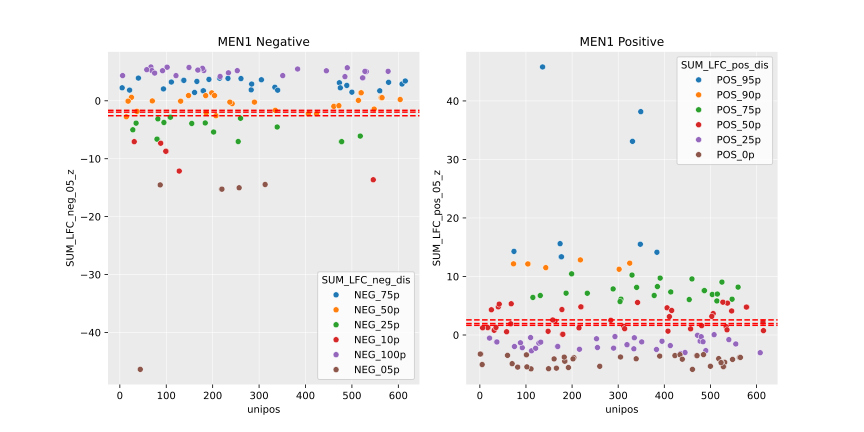

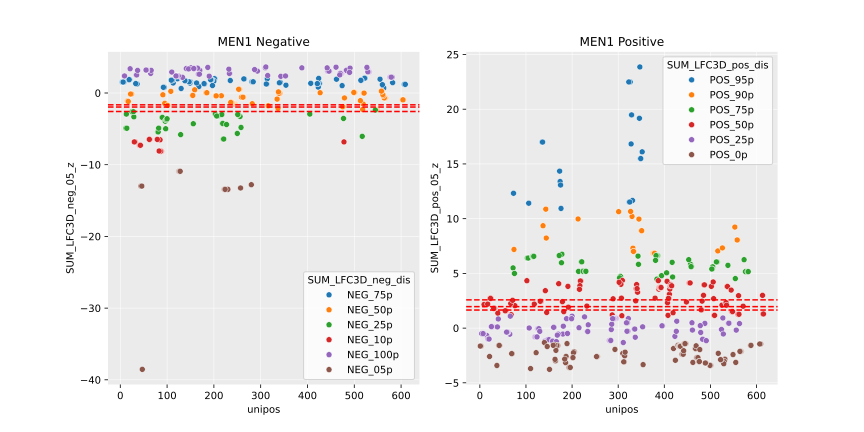

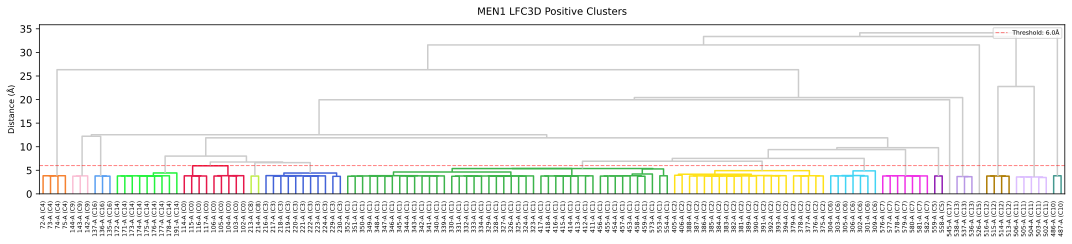

In [ ]:
# @title BE-MetaClust3D and Visualizations
# @markdown Description

! python bemetaclust3d_metaaggregate.py {yaml_config_filepath}

display(SVG(filename=f'{output_dir}meta-aggregate/plots/{input_gene}_LFC_cutoff05_scatter_colored.svg'))
display(SVG(filename=f'{output_dir}meta-aggregate/plots/{input_gene}_LFC3D_cutoff05_scatter_colored.svg'))
display(SVG(filename=f'{output_dir}cluster_LFC3D/plots/{input_gene}_Meta_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))


All results will be saved in the following directory: /content/MEN1/
MEN1 PernerNature2023-MOLM13-Screen
MEN1 PernerNature2023-MV411-Screen
Output from beclust3d.lfc3d.characterization is saved in the following directory: /content/MEN1/characterization/
Step 3b complete: meta characterization done


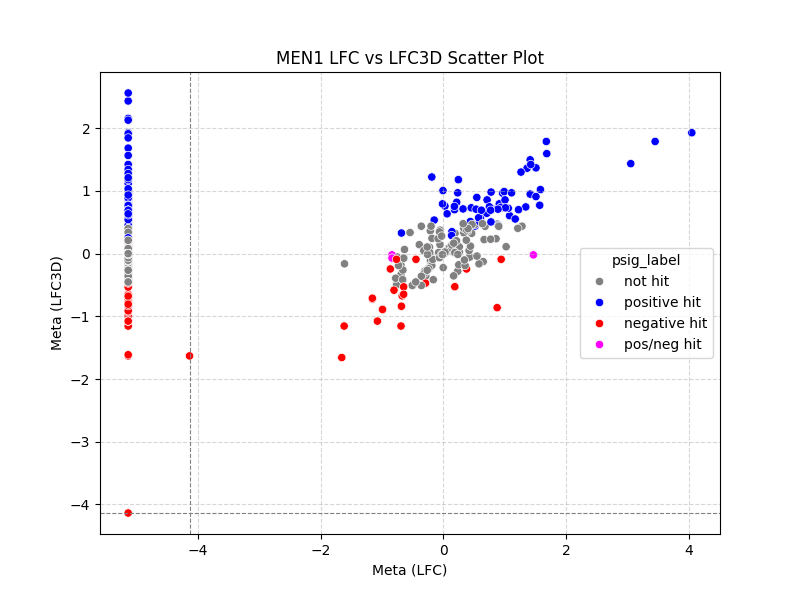

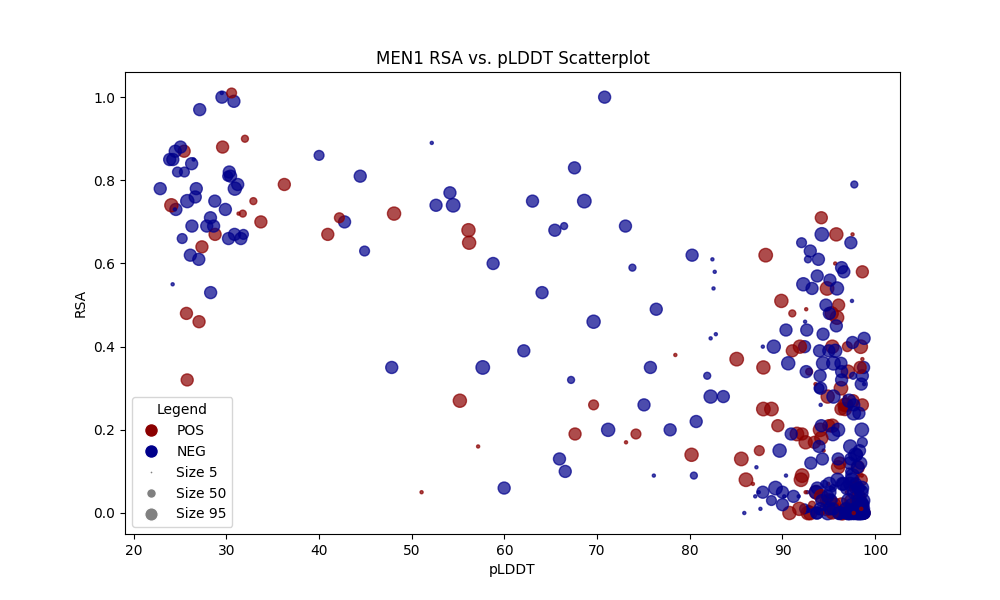

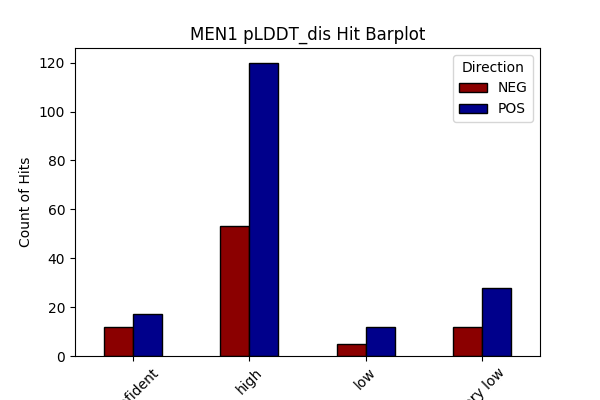

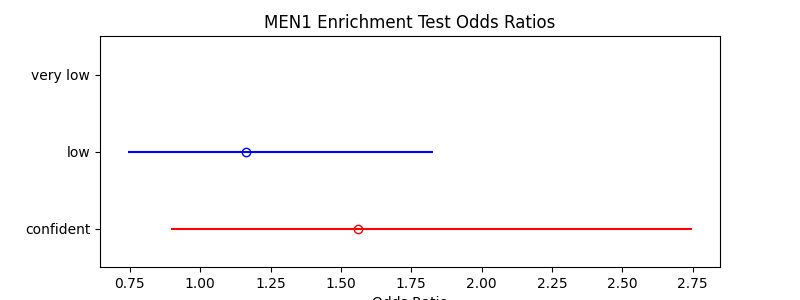

In [ ]:
# @title BE-MetaClust3D Characterization and Visualizations

! python bemetaclust3d_characterization.py {yaml_config_filepath}

display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_LFC_LFC3D_scatter_05_Meta.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_pLDDT_RSA_scatter.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_Count_pLDDT_dis_barplot_LFC3D_05.png'))
display(Image(filename=f'{output_dir}characterization/plots/{input_gene}_enrichment_test_LFC3D_05.png'))
